In [2]:
import importlib

import numpy as np
import os
import pandas as pd
import random
from lifelines import CoxPHFitter

import test_WTM as wtm
import utilsA1 as utils
import gudhi_persistence as gp

PATH = os.getcwd()
output_file = "cox_proportional_models"
print(PATH)

C:\Users\sranasin\Desktop\NetworkModels\Project1\A1


#### Test And Visualizations

In [16]:
importlib.reload(utils)
importlib.reload(wtm)
importlib.reload(gp)

params_temp_list = {'num_nodes': 100, 'num_neighbor_nodes': 1,
                    'total_random_edges': 2, 'distance_threshold': 2, 'weighted': False,
                    'ngeo_placement': 'ngeo_per_node', 'n_seeds': 1, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
                    'seeding_method': 'all_combinations'}

params_temp_list['threshold_sum']= sum(range(params_temp_list['num_nodes'])) -1

G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
G, snapshots, activation_times, results = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
max_steps = 100, sim_id = 1, realization_id = 1)


#### Cox Proportional Hazard Model

In [19]:
importlib.reload(utils)
importlib.reload(wtm)
importlib.reload(gp)
###############
## Simulation Runs
params_list = utils.generate_random_params(num_samples=1)
np.random.seed(666)
random.seed(666)


df, activation_results = wtm.main_sims(params_list=[params_temp_list],
                   output_file=output_file, save_files=False)
# df = pd.read_csv(os.path.join(PATH, 'Outputs', f"{output_file}.csv"))

In [20]:
df

,simulation_id,realization_id,num_nodes,time,state,state_abnormal_sum,num_active_nodes,active_nodes,node_active_threshold,H0,...,total_geo_edges,total_non_geo_edges,num_seeds,seed_nodes,seed_cluster_distance,weighted,average_weight_per_edge,skew_power,upper_weight_limit,distance_threshold
0,0,0,100,0,0,4949,1,"[0.0, nan, nan, nan, nan, nan, nan, nan, nan, ...",0.01,1,...,100,100,1,"(0,)",10,False,0.0,3,5,2
1,0,0,100,1,0,4949,5,"[0.0, 1.0, nan, nan, nan, nan, nan, nan, nan, ...",0.01,3,...,100,100,1,"(0,)",10,False,0.0,3,5,2
2,0,0,100,2,0,4949,16,"[0.0, 1.0, 2.0, 2.0, nan, nan, 2.0, nan, nan, ...",0.01,7,...,100,100,1,"(0,)",10,False,0.0,3,5,2
3,0,0,100,3,0,4949,43,"[0.0, 1.0, 2.0, 2.0, 3.0, 3.0, 2.0, 3.0, 3.0, ...",0.01,14,...,100,100,1,"(0,)",10,False,0.0,3,5,2
4,0,0,100,4,0,4949,84,"[0.0, 1.0, 2.0, 2.0, 3.0, 3.0, 2.0, 3.0, 3.0, ...",0.01,11,...,100,100,1,"(0,)",10,False,0.0,3,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,0,99,100,1,0,4949,5,"[1.0, nan, nan, 1.0, nan, nan, 1.0, nan, nan, ...",0.01,3,...,100,100,1,"(99,)",10,False,0.0,3,5,2
621,0,99,100,2,0,4949,16,"[1.0, 2.0, 2.0, 1.0, 2.0, 2.0, 1.0, 2.0, nan, ...",0.01,6,...,100,100,1,"(99,)",10,False,0.0,3,5,2
622,0,99,100,3,0,4949,41,"[1.0, 2.0, 2.0, 1.0, 2.0, 2.0, 1.0, 2.0, 3.0, ...",0.01,13,...,100,100,1,"(99,)",10,False,0.0,3,5,2
623,0,99,100,4,0,4949,79,"[1.0, 2.0, 2.0, 1.0, 2.0, 2.0, 1.0, 2.0, 3.0, ...",0.01,11,...,100,100,1,"(99,)",10,False,0.0,3,5,2


In [26]:
grouped = df.groupby(['simulation_id', 'realization_id'])

records = []

for sim_id, group in grouped:
    abnormal_records = group[group['state'] == 1]
    max_h0 = group['H0'].max()
    max_h1 = group['H1'].max()
    if not abnormal_records.empty:
        row = abnormal_records.iloc[0]
        time_to_event = row['time']
        state = 1
    else:
        row = group.iloc[-1]
        time_to_event = row['time']
        state = 0

    features = row.drop(['time'
                         # 'state', 'simulation_id', 'realization_id', 'state_abnormal_sum',
                         # 'active_nodes', 'num_nodes', 'num_active_nodes',  'node_active_threshold', 'skew_power',
                         # 'seed_nodes', 'average_weight_per_edge', 'H0', 'H2'
                         ]).to_dict()

    records.append({
        'duration': time_to_event,
        'state': state,
        'max_h0': max_h0,
        'max_h1': max_h1,
        **features
    })

cox_df = pd.DataFrame(records)
cox_df['is_weighted'] = cox_df['weighted'].astype(int)
cox_df.drop(columns = ['weighted'], inplace=True)

# cox_df['state'].value_counts()
print(cox_df[cox_df['state'] ==0]['duration'].value_counts().sort_index())
cox_df.head()
# cox_df = cox_df[cox_df['state'] == 1]

Series([], Name: count, dtype: int64)


,duration,state,max_h0,max_h1,simulation_id,realization_id,num_nodes,state_abnormal_sum,num_active_nodes,active_nodes,...,total_geo_edges,total_non_geo_edges,num_seeds,seed_nodes,seed_cluster_distance,average_weight_per_edge,skew_power,upper_weight_limit,distance_threshold,is_weighted
0,5,1,14,1,0,0,100,4949,100,"[0.0, 1.0, 2.0, 2.0, 3.0, 3.0, 2.0, 3.0, 3.0, ...",...,100,100,1,"(0,)",10,0.0,3,5,2,0
1,5,1,16,1,0,1,100,4949,100,"[1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 3.0, 4.0, 4.0, ...",...,100,100,1,"(1,)",10,0.0,3,5,2,0
2,6,1,15,1,0,2,100,4949,100,"[2.0, 1.0, 0.0, 1.0, 2.0, 3.0, 3.0, 4.0, 3.0, ...",...,100,100,1,"(2,)",10,0.0,3,5,2,0
3,6,1,12,1,0,3,100,4949,100,"[2.0, 2.0, 1.0, 0.0, 1.0, 2.0, 2.0, 3.0, 3.0, ...",...,100,100,1,"(3,)",10,0.0,3,5,2,0
4,5,1,12,1,0,4,100,4949,100,"[3.0, 3.0, 2.0, 1.0, 0.0, 1.0, 2.0, 3.0, 4.0, ...",...,100,100,1,"(4,)",10,0.0,3,5,2,0


In [25]:
cox_df

,duration,state,realization_id,node_active_threshold,H1,total_geo_edges,total_non_geo_edges,num_seeds,seed_cluster_distance,skew_power,upper_weight_limit,distance_threshold,is_weighted
0,5,1,0,0.01,1,100,100,1,10,3,5,2,0


Iteration 1: norm_delta = 3.03e+00, step_size = 0.9500, log_lik = -33.50507, newton_decrement = 1.46e+01, seconds_since_start = 0.0
Iteration 2: norm_delta = 1.48e+00, step_size = 0.9500, log_lik = -21.62143, newton_decrement = 4.00e+00, seconds_since_start = 0.0
Iteration 3: norm_delta = 1.45e+00, step_size = 0.9500, log_lik = -17.75184, newton_decrement = 1.34e+00, seconds_since_start = 0.0
Iteration 4: norm_delta = 3.44e+00, step_size = 1.0000, log_lik = -15.96806, newton_decrement = 1.39e+00, seconds_since_start = 0.0
Iteration 5: norm_delta = 3.93e+00, step_size = 0.9800, log_lik = -14.13418, newton_decrement = 7.09e-01, seconds_since_start = 0.0
Iteration 6: norm_delta = 3.89e+00, step_size = 0.9604, log_lik = -13.26952, newton_decrement = 2.92e-01, seconds_since_start = 0.0
Iteration 7: norm_delta = 3.87e+00, step_size = 0.9412, log_lik = -12.90844, newton_decrement = 1.20e-01, seconds_since_start = 0.0
Iteration 8: norm_delta = 1.39e+00, step_size = 1.0000, log_lik = -12.76803,

<lifelines.CoxPHFitter: fitted with 17 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'state'
      baseline estimation = breslow
   number of observations = 17
number of events observed = 17
   partial log-likelihood = -12.76
         time fit was run = 2025-07-27 07:34:10 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
node_active_threshold 69.60  1.69e+30     44.17          -16.97          156.18                0.00            6.74e+67
H1                     0.05      1.05      0.02            0.00            0.09                1.00                1.09
num_non_geo_edges      0.89      2.43      0.46           -0.02            1.79                0.98                5.98
num_seeds              5.11    165.05      2.58            0.06           10.16                1.06            25767.34
seed_cluster_distance  0.44      1.55      0.22            0.01            0.86                1.01                2.37
skew_power            12.54  2.80e+05      7.48           -2.12           27.20                0.12            6.48e+11
upper_weight_limit    -0.90      0.41      0.53           -1.93            0.13                0.14                1.14
distance_threshold    -4.06      0.02      2.28           -8.53            0.41                0.00                1.51
is_weighted            1.11      3.02      3.18           -5.13            7.34                0.01             1536.78

                       cmp to     z    p  -log2(p)
covariate                                         
node_active_threshold    0.00  1.58 0.12      3.12
H1                       0.00  2.04 0.04      4.61
num_non_geo_edges        0.00  1.93 0.05      4.21
num_seeds                0.00  1.98 0.05      4.40
seed_cluster_distance    0.00  2.00 0.05      4.47
skew_power               0.00  1.68 0.09      3.42
upper_weight_limit       0.00 -1.71 0.09      3.51
distance_threshold       0.00 -1.78 0.07      3.74
is_weighted              0.00  0.35 0.73      0.46
---
Concordance = 0.96
Partial AIC = 43.52
log-likelihood ratio test = 41.49 on 9 df
-log2(p) of ll-ratio test = 17.91

<Axes: xlabel='log(HR) (95% CI)'>

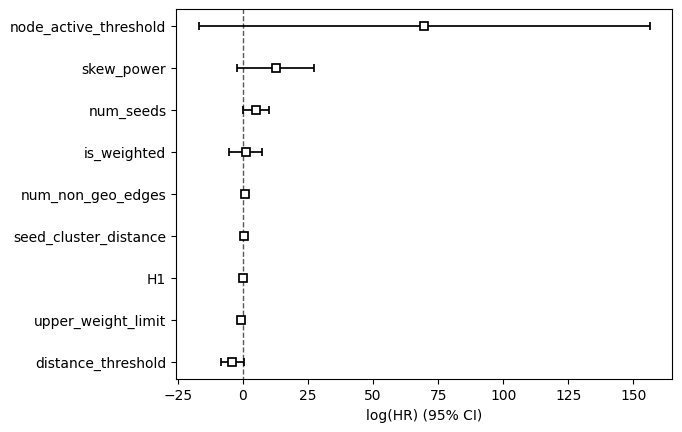

In [83]:
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration', event_col = 'state', show_progress=True)
cph.print_summary()
cph.plot()

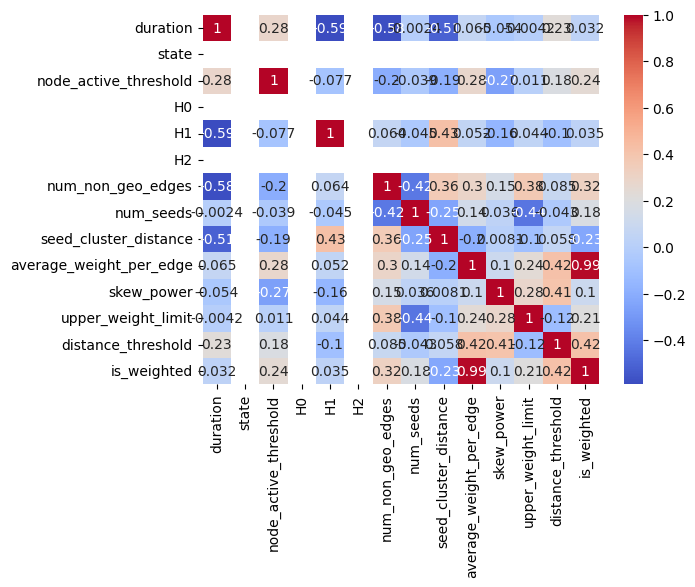

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = cox_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [118]:
# def load_simulations(file_path):
#     with open(file_path, 'rb') as f:
#         return pickle.load(f)

# simulations_time_series = load_simulations(pkl)
#
# activation_series = []
# for sim in simulations_time_series:
#     sim_id = sim['sim_id']
#     G = sim['graph']
#     activation_series.append(sim['activation_times'])
#
#     print(f"Sim {sim_id} — Nodes: {len(G)}, Activated: {sum(~np.isnan(sim['activation_times']))}")
#
# print(activation_series[0])

Sim 0 — Nodes: 200, Activated: 200
Sim 1 — Nodes: 200, Activated: 200
Sim 2 — Nodes: 200, Activated: 200
Sim 3 — Nodes: 200, Activated: 200
Sim 4 — Nodes: 200, Activated: 200
Sim 5 — Nodes: 200, Activated: 200
Sim 6 — Nodes: 200, Activated: 200
Sim 7 — Nodes: 200, Activated: 200
Sim 8 — Nodes: 200, Activated: 200
Sim 9 — Nodes: 200, Activated: 200
[12. 12. 13. 13. 13. 13. 12. 12. 12. 11. 11. 11. 10. 10. 10.  9.  9.  9.
  8.  8.  9.  7.  8.  8.  7.  7.  6.  6.  6.  5.  5.  5.  4.  4.  4.  3.
  3.  2.  1.  2.  1.  0.  1.  1.  2.  2.  2.  3.  3.  4.  4.  4.  5.  5.
  5.  6.  6.  7.  7.  8.  8.  8.  9.  9.  9. 10. 10. 10. 11. 11. 11. 11.
 11. 10. 10. 10.  9. 10. 10. 10. 11. 11. 11. 12. 12. 12. 13. 13. 13. 14.
 14. 14. 15. 15. 15. 15. 14. 14. 14. 13. 13. 13. 12. 12. 12. 11. 11. 11.
 10. 10. 10.  9.  9.  9.  8.  8.  8.  7.  7.  7.  6.  6.  6.  5.  5.  5.
  4.  4.  3.  3.  3.  2.  2.  2.  1.  2.  0.  1.  1.  1.  2.  2.  2.  2.
  1.  2.  1.  0.  2.  1.  2.  2.  3.  3.  2.  2.  2.  1.  0.  1.  